In [2]:
# ============================================================
# 라이브러리 임포트
# ============================================================
import pandas as pd
import numpy as np
import yfinance as yf
import os, warnings, time

warnings.filterwarnings('ignore')

# ── 경로 설정 ──
V3_DIR   = os.getcwd()  # Final_Project/
DATA_DIR = os.path.join(V3_DIR, 'data')
IMG_DIR  = os.path.join(V3_DIR, 'images')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

# ── 기간 설정 ──────────────────────────────────────────────────
# WARMUP_START : 파생변수 롤링 윈도우 안정화를 위한 사전 수집 시작일
#   - claims_zscore : 260일 롤링 (가장 긴 윈도우, 약 1년 필요)
#   - SKEW_zscore   : 63일 롤링
#   - Cu_Au_ratio_chg, rv_neutral : 21일 롤링
#   → 2014-01-01 시작 시 2016-01-01 기준 약 504 거래일 확보 (260일의 2배)
# ANALYSIS_START : 실제 분석 시작일 (Step2에서 슬라이싱 기준으로 사용)
# BTC-USD 주의 : 2014-09 이후 데이터 존재 → 워밍업 8개월만 결측, ffill로 무해
WARMUP_START   = '2014-01-01'
ANALYSIS_START = '2016-01-01'
END            = '2025-12-31'

print(f'데이터 수집 : {WARMUP_START} ~ {END} (워밍업 포함)')
print(f'실제 분석   : {ANALYSIS_START} ~ {END}')
print(f'저장 경로   : {DATA_DIR}')

데이터 수집 : 2014-01-01 ~ 2025-12-31 (워밍업 포함)
실제 분석   : 2016-01-01 ~ 2025-12-31
저장 경로   : c:\workspace\camp\project\finance_project\서윤범\data


In [1]:
import os
from dotenv import load_dotenv
from fredapi import Fred

load_dotenv('api.env')  # .env 파일 로드
fred_client = Fred(api_key=os.environ["FRED_API_KEY"])

1단계: BAA10Y 수집 가능성 확인
BAA10Y 범위   : 2014-01-01 ~ 2025-12-31
관측치 개수   : 3,131개
NaN 개수      : 135개
✅ 전체 기간 확보

2단계: BAMLH0A0HYM2와 BAA10Y 상관관계 (공통 3년)
공통 관측일 : 676일

기초 통계:
       HY_spread   BAA10Y
count    676.000  676.000
mean       3.365    1.692
std        0.555    0.186
min        2.590    1.360
25%        2.930    1.540
50%        3.190    1.690
75%        3.792    1.800
max        4.950    2.280

레벨 상관  : 0.774
변화 상관  : 0.642  ← 더 중요

HY/BAA 평균 비율: 1.99배

3단계: 주요 스트레스 이벤트 반응 비교 (2023~2025)
  2023-10-이스라엘-하마스          | HY Δ=+0.42%p | BAA Δ=+0.10%p
  2024-08-일본 엔캐리            | HY Δ=+0.62%p | BAA Δ=+0.17%p
  2025-04-관세 쇼크             | HY Δ=+1.19%p | BAA Δ=+0.29%p


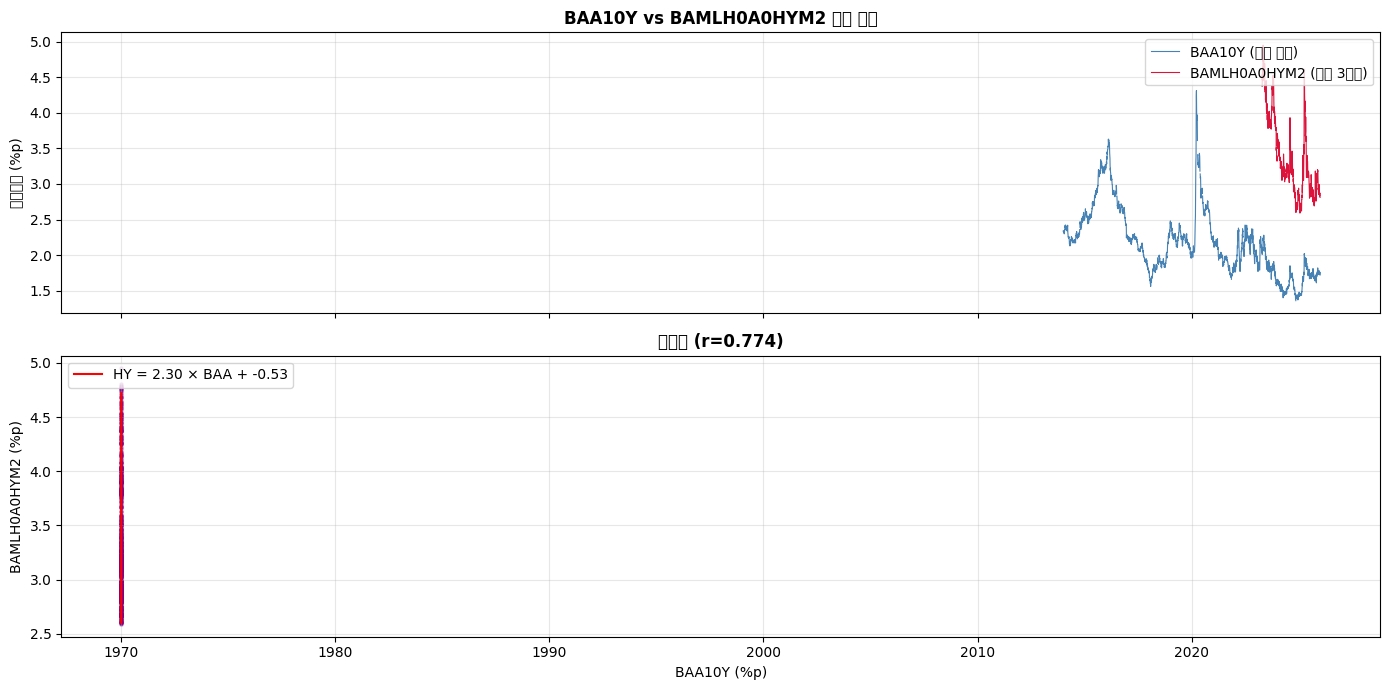


최종 판단 가이드
✅ BAA10Y 채택 조건:
   - 수집 관측치 > 2,400개 (전체 기간)
   - 변화 상관 > 0.60
   - 주요 이벤트에서 방향 일치

⚠️ 재검토 필요 조건:
   - 이벤트 반응이 일관되지 않음
   - 변화 상관 < 0.50


In [3]:
# ═══════════════════════════════════════════════════════════
# BAA10Y 실용성 검증 (3단계)
# ═══════════════════════════════════════════════════════════
from pathlib import Path
from dotenv import load_dotenv, find_dotenv
from fredapi import Fred
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

load_dotenv(find_dotenv())
fred_client = Fred(api_key=os.environ["FRED_API_KEY"])


# ── 1단계: 수집 가능성 ─────────────────────────────────────
print('=' * 70)
print('1단계: BAA10Y 수집 가능성 확인')
print('=' * 70)
s_baa = fred_client.get_series('BAA10Y',
                                 observation_start='2014-01-01',
                                 observation_end='2025-12-31')
print(f'BAA10Y 범위   : {s_baa.index[0].date()} ~ {s_baa.index[-1].date()}')
print(f'관측치 개수   : {len(s_baa):,}개')
print(f'NaN 개수      : {s_baa.isnull().sum()}개')
print(f'✅ 전체 기간 확보' if len(s_baa) > 2400 else '⚠️ 기간 제약 있음')


# ── 2단계: BAMLH0A0HYM2와 상관관계 (공통 기간만) ───────────
print('\n' + '=' * 70)
print('2단계: BAMLH0A0HYM2와 BAA10Y 상관관계 (공통 3년)')
print('=' * 70)
s_hy = fred_client.get_series('BAMLH0A0HYM2',
                                observation_start='2023-04-18',
                                observation_end='2025-12-31')

common = pd.concat([s_hy, s_baa], axis=1).dropna()
common.columns = ['HY_spread', 'BAA10Y']

print(f'공통 관측일 : {len(common):,}일')
print(f'\n기초 통계:')
print(common.describe().round(3).to_string())

print(f'\n레벨 상관  : {common.corr().iloc[0,1]:.3f}')
print(f'변화 상관  : {common.diff().corr().iloc[0,1]:.3f}  ← 더 중요')

ratio = common['HY_spread'].mean() / common['BAA10Y'].mean()
print(f'\nHY/BAA 평균 비율: {ratio:.2f}배')


# ── 3단계: 스트레스 이벤트 반응 비교 (2023~2025) ──────────
print('\n' + '=' * 70)
print('3단계: 주요 스트레스 이벤트 반응 비교 (2023~2025)')
print('=' * 70)
events = {
    '2023-03-SVB 사태':     ('2023-03-01', '2023-03-31'),
    '2023-10-이스라엘-하마스': ('2023-10-01', '2023-10-31'),
    '2024-08-일본 엔캐리':    ('2024-08-01', '2024-08-15'),
    '2025-04-관세 쇼크':     ('2025-04-01', '2025-04-30'),
}
for name, (s, e) in events.items():
    try:
        window = common.loc[s:e]
        if len(window) == 0:
            continue
        hy_chg  = window['HY_spread'].max() - window['HY_spread'].min()
        baa_chg = window['BAA10Y'].max()  - window['BAA10Y'].min()
        print(f'  {name:25s} | HY Δ={hy_chg:+.2f}%p | BAA Δ={baa_chg:+.2f}%p')
    except KeyError:
        continue


# ── 시각화 ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.plot(s_baa.index, s_baa.values, color='steelblue', linewidth=0.8, label='BAA10Y (전체 기간)')
ax.plot(s_hy.index, s_hy.values, color='crimson', linewidth=0.8, label='BAMLH0A0HYM2 (최근 3년만)')
ax.set_ylabel('스프레드 (%p)')
ax.set_title('BAA10Y vs BAMLH0A0HYM2 수준 비교', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

ax = axes[1]
if len(common) > 0:
    ax.scatter(common['BAA10Y'], common['HY_spread'], s=5, alpha=0.4, color='purple')
    z = np.polyfit(common['BAA10Y'], common['HY_spread'], 1)
    xx = np.linspace(common['BAA10Y'].min(), common['BAA10Y'].max(), 100)
    ax.plot(xx, np.polyval(z, xx), color='red', linewidth=1.5,
            label=f'HY = {z[0]:.2f} × BAA + {z[1]:.2f}')
    ax.set_xlabel('BAA10Y (%p)')
    ax.set_ylabel('BAMLH0A0HYM2 (%p)')
    ax.set_title(f'산점도 (r={common.corr().iloc[0,1]:.3f})', fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ── 최종 판단 ─────────────────────────────────────────────
print('\n' + '=' * 70)
print('최종 판단 가이드')
print('=' * 70)
print('✅ BAA10Y 채택 조건:')
print('   - 수집 관측치 > 2,400개 (전체 기간)')
print('   - 변화 상관 > 0.60')
print('   - 주요 이벤트에서 방향 일치')
print('\n⚠️ 재검토 필요 조건:')
print('   - 이벤트 반응이 일관되지 않음')
print('   - 변화 상관 < 0.50')

In [4]:
# ============================================================
# 티커 정의
# ============================================================

# ── 투자 자산 (30개) ──
INDEX_ETF  = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']
BOND_ETF   = ['TLT', 'AGG', 'SHY', 'TIP']
ALT_ETF    = ['GLD', 'DBC']
SECTOR_ETF = ['XLK', 'XLF', 'XLE', 'XLV', 'VOX',
              'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']
STOCKS     = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']

# 전체 투자 자산
ALL_PORTFOLIO = INDEX_ETF + BOND_ETF + ALT_ETF + SECTOR_ETF + STOCKS
print(f'투자 자산: {len(ALL_PORTFOLIO)}개')
print(f'  인덱스 ETF: {INDEX_ETF}')
print(f'  채권 ETF:   {BOND_ETF}')
print(f'  대안 ETF:   {ALT_ETF}')
print(f'  섹터 ETF:   {SECTOR_ETF}')
print(f'  개별 종목:  {STOCKS}')

# ── 외부 지표 (6개, 투자하지 않고 관찰만) ──
# ETH-USD 제거: (1) yfinance 2015-08 이전 데이터 없음 → 워밍업 구간 결측
#              (2) 파이프라인 후속 단계(HMM/Config C)에서 미사용
#              (3) BTC-USD만으로도 암호화폐 시장 움직임은 충분히 포착
EXTERNAL = {
    'CL=F':    'WTI 원유 선물',
    'GC=F':    '금 선물 (COMEX)',
    'SI=F':    '은 선물 (COMEX)',
    'BTC-USD': '비트코인',
    '^VIX':    'VIX (공포 지수)',
    'DX-Y.NYB':'DXY (달러 인덱스)',
}
print(f'\n외부 지표: {len(EXTERNAL)}개 — {list(EXTERNAL.keys())}')

# ── 대안데이터 yfinance (5개) ──
ALT_YF = {
    '^VIX9D': 'VIX 9-Day (초단기 내재 변동성)',
    '^VIX3M': 'VIX 3-Month (중기 내재 변동성)',
    '^VIX6M': 'VIX 6-Month (장기 내재 변동성)',
    '^SKEW':  'CBOE SKEW Index (꼬리 위험)',
    'HG=F':   'Copper Futures (구리 선물)',
}
print(f'대안 yfinance: {len(ALT_YF)}개 — {list(ALT_YF.keys())}')

# ── 대안데이터 FRED (5개) ──
ALT_FRED = {
    'BAA10Y':       'Moody Baa - 10Y 신용스프레드 (HY 대체)',  # ← 변경
    'T10Y2Y':       '10Y-2Y 수익률 곡선 스프레드',
    'ICSA':         '신규 실업수당 청구 (주간)',
    'WEI':          'Weekly Economic Index (주간)',
    'SAHMREALTIME': 'Sahm 경기침체 지표 (월간)',
}

# ── 기존 FRED 매크로 (3개) ──
MACRO_FRED = {
    'DGS10':    '미국 10Y 국채 수익률',
    'CPIAUCSL': '소비자물가지수 (CPI)',
    'UNRATE':   '실업률',
}
print(f'FRED 대안: {len(ALT_FRED)}개, 기존 매크로: {len(MACRO_FRED)}개')
print(f'\n총 수집 대상: {len(ALL_PORTFOLIO) + len(EXTERNAL) + len(ALT_YF) + len(ALT_FRED) + len(MACRO_FRED)}개')

투자 자산: 30개
  인덱스 ETF: ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']
  채권 ETF:   ['TLT', 'AGG', 'SHY', 'TIP']
  대안 ETF:   ['GLD', 'DBC']
  섹터 ETF:   ['XLK', 'XLF', 'XLE', 'XLV', 'VOX', 'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']
  개별 종목:  ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']

외부 지표: 6개 — ['CL=F', 'GC=F', 'SI=F', 'BTC-USD', '^VIX', 'DX-Y.NYB']
대안 yfinance: 5개 — ['^VIX9D', '^VIX3M', '^VIX6M', '^SKEW', 'HG=F']
FRED 대안: 5개, 기존 매크로: 3개

총 수집 대상: 49개


In [5]:
# ============================================================
# yfinance 일괄 수집 (41개 티커) — WARMUP_START 부터 수집
# ============================================================
# 수집 구성: 투자 자산 30 + 외부 지표 6 + 대안 yfinance 5 = 41개
# (ETH-USD 제거: 2015-08 이전 데이터 없음 + 후속 단계 미사용)

all_yf_tickers = ALL_PORTFOLIO + list(EXTERNAL.keys()) + list(ALT_YF.keys())
print(f'yfinance 수집 대상: {len(all_yf_tickers)}개 티커')
print(f'수집 기간: {WARMUP_START} ~ {END} (워밍업 포함)\n')

# 개별 수집 (안정성 우선)
yf_data = {}
failed  = []

for i, ticker in enumerate(all_yf_tickers, 1):
    try:
        # WARMUP_START 부터 수집 (2014-01-01)
        df = yf.download(ticker, start=WARMUP_START, end=END,
                         auto_adjust=True, progress=False)
        if df.empty:
            print(f'  [{i:2d}/{len(all_yf_tickers)}] [WARN] {ticker:12s} — 데이터 없음')
            failed.append(ticker)
            continue
        # Close 가격 추출 (MultiIndex 대응)
        if isinstance(df.columns, pd.MultiIndex):
            series = df[('Close', ticker)].dropna()
        else:
            series = df['Close'].dropna()
        yf_data[ticker] = series
        if i % 10 == 0 or i == len(all_yf_tickers):
            print(f'  [{i:2d}/{len(all_yf_tickers)}] {ticker:12s} — {len(series):,}일 수집 완료')
    except Exception as e:
        print(f'  [{i:2d}/{len(all_yf_tickers)}] [ERR] {ticker:12s} — {e}')
        failed.append(ticker)

# BTC-USD 최초 거래일 확인 (암호화폐 관찰 지표로 유지)
if 'BTC-USD' in yf_data:
    print(f'\nBTC-USD 최초 거래일: {yf_data["BTC-USD"].first_valid_index().date()}')

print(f'\n수집 완료: {len(yf_data)}개 성공, {len(failed)}개 실패')
if failed:
    print(f'실패 티커: {failed}')

yfinance 수집 대상: 41개 티커
수집 기간: 2014-01-01 ~ 2025-12-31 (워밍업 포함)

  [10/41] GLD          — 3,017일 수집 완료
  [20/41] XLU          — 3,017일 수집 완료
  [30/41] XOM          — 3,017일 수집 완료
  [40/41] ^SKEW        — 2,960일 수집 완료
  [41/41] HG=F         — 3,017일 수집 완료

BTC-USD 최초 거래일: 2014-09-17

수집 완료: 41개 성공, 0개 실패


In [6]:
# ============================================================
# DataFrame 병합 + SPY 실거래일 기준 정렬
# ============================================================

# 전체 DataFrame 구성
df_all_prices = pd.DataFrame(yf_data)
df_all_prices.index = pd.to_datetime(df_all_prices.index)
df_all_prices = df_all_prices.sort_index()

# ── 수정 1: SPY 실거래일을 기준 인덱스로 사용 ──────────────────
# pd.bdate_range(freq='B')는 NYSE 공휴일(MLK Day, Good Friday 등)을 포함해 잘못된 인덱스 생성
# SPY는 NYSE 상장 ETF이므로 SPY.dropna().index = 실제 NYSE 영업일
spy_trading_days = yf_data['SPY'].dropna().index
df_all_prices = df_all_prices.reindex(spy_trading_days)

# ── 수정 2: ffill() 단독 사용, bfill() 제거 ────────────────────
# ffill  : 직전 종가 유지 ("공휴일엔 가격 불변") → 경제적으로 합리적
# bfill  : 미래값으로 과거 채움 → look-ahead bias 발생, 사용 금지
df_all_prices = df_all_prices.ffill()

# 맨 앞 NaN 행 제거 (ffill로 채울 이전 데이터가 없는 시작 구간)
df_all_prices = df_all_prices.dropna(how='all')
df_all_prices.index.name = 'Date'

print(f'전체 시세 DataFrame : {df_all_prices.shape}')
print(f'기간 : {df_all_prices.index[0].date()} ~ {df_all_prices.index[-1].date()}')
print(f'  (워밍업 포함: {WARMUP_START} ~ {END})')
print(f'\n결측률:')
missing = df_all_prices.isnull().sum()
if missing.sum() == 0:
    print('  전 컬럼 결측 0개')
else:
    print(missing[missing > 0])

전체 시세 DataFrame : (3017, 41)
기간 : 2014-01-02 ~ 2025-12-30
  (워밍업 포함: 2014-01-01 ~ 2025-12-31)

결측률:
XLRE       445
BTC-USD    178
dtype: int64


In [7]:
# ============================================================
# 투자 자산과 외부/대안 지표 분리 저장
# ============================================================

# 투자 자산 (30개) — 실제 매매 대상
port_cols = [c for c in ALL_PORTFOLIO if c in df_all_prices.columns]
df_portfolio = df_all_prices[port_cols]

# 외부 지표 + 대안 yfinance (12개) — 관찰만
ext_alt_cols = [c for c in list(EXTERNAL.keys()) + list(ALT_YF.keys()) if c in df_all_prices.columns]
df_ext_alt = df_all_prices[ext_alt_cols]

print(f'투자 자산: {df_portfolio.shape} — {list(df_portfolio.columns)}')
print(f'외부+대안: {df_ext_alt.shape} — {list(df_ext_alt.columns)}')

투자 자산: (3017, 30) — ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'AGG', 'SHY', 'TIP', 'GLD', 'DBC', 'XLK', 'XLF', 'XLE', 'XLV', 'VOX', 'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']
외부+대안: (3017, 11) — ['CL=F', 'GC=F', 'SI=F', 'BTC-USD', '^VIX', 'DX-Y.NYB', '^VIX9D', '^VIX3M', '^VIX6M', '^SKEW', 'HG=F']


In [24]:
# ============================================================
# FRED 수집 (8개 시리즈) — WARMUP_START 부터 수집
# ============================================================

from fredapi import Fred

fred_client = Fred(api_key=os.environ["FRED_API_KEY"])

def get_fred(series_id: str, start: str, end: str) -> pd.Series:
    s = fred_client.get_series(
        series_id,
        observation_start=start,
        observation_end=end
    )
    s.name = series_id
    return s.dropna()


ALL_FRED = {**ALT_FRED, **MACRO_FRED}  # 5 + 3 = 8개
fred_data = {}

for series_id, desc in ALL_FRED.items():
    try:
        # WARMUP_START 부터 수집 (2014-01-01)
        s = get_fred(series_id, WARMUP_START, END)
        fred_data[series_id] = s
        print(f'  [OK] {series_id:20s} ({desc}) — {len(s):,}개 관측치')
    except Exception as e:
        print(f'  [ERR] {series_id:20s} ({desc}) — {e}')

df_fred_raw = pd.DataFrame(fred_data)
df_fred_raw.index = pd.to_datetime(df_fred_raw.index)
print(f'\nFRED 원시: {df_fred_raw.shape}')
print(f'기간: {df_fred_raw.index[0].date()} ~ {df_fred_raw.index[-1].date()}')

  [OK] BAA10Y               (Moody Baa - 10Y 신용스프레드 (HY 대체)) — 2,996개 관측치
  [OK] T10Y2Y               (10Y-2Y 수익률 곡선 스프레드) — 3,000개 관측치
  [OK] ICSA                 (신규 실업수당 청구 (주간)) — 626개 관측치
  [OK] WEI                  (Weekly Economic Index (주간)) — 626개 관측치
  [OK] SAHMREALTIME         (Sahm 경기침체 지표 (월간)) — 143개 관측치
  [OK] DGS10                (미국 10Y 국채 수익률) — 3,000개 관측치
  [OK] CPIAUCSL             (소비자물가지수 (CPI)) — 143개 관측치
  [OK] UNRATE               (실업률) — 143개 관측치

FRED 원시: (3657, 8)
기간: 2014-01-01 ~ 2025-12-31


In [25]:
# ============================================================
# FRED → 달력일 ffill → SPY 실거래일 필터
# ============================================================
#
# 왜 2단계로 하는가?
#   ICSA(실업수당)는 토요일에 발표 → NYSE 영업일에 직접 reindex하면 결측
#   달력일(매일) 기준으로 ffill하면 토요일 값이 월~금으로 전파
#   그 후 SPY 실거래일만 필터 (NYSE 공휴일 자동 제외)
#
# ── 수정: START → WARMUP_START, bfill() 제거, nyse_dates → spy_trading_days ──
# bfill()은 미래값으로 과거를 채우는 look-ahead bias 발생 → 사용 금지

daily_range = pd.date_range(start=WARMUP_START, end=END, freq='D')
df_fred_daily = df_fred_raw.reindex(daily_range).ffill()
df_fred = df_fred_daily.reindex(spy_trading_days)
df_fred.index.name = 'Date'

print(f'FRED 정렬 후: {df_fred.shape}')
print(f'결측률:')
fred_missing = df_fred.isnull().sum()
if fred_missing.sum() == 0:
    print('  전 컬럼 결측 0개')
else:
    print(fred_missing[fred_missing > 0])

FRED 정렬 후: (3017, 8)
결측률:
ICSA    2
WEI     2
dtype: int64


In [26]:
# ============================================================
# 전체 결측률 리포트
# ============================================================

all_data = pd.concat([df_all_prices, df_fred], axis=1)
total = len(all_data)

report = pd.DataFrame({
    '컬럼': all_data.columns,
    '총 행수': total,
    '결측 수': all_data.isnull().sum().values,
    '결측률(%)': (all_data.isnull().sum().values / total * 100).round(2),
})

# 결측 있는 것만 출력 (없으면 "전부 0" 메시지)
has_missing = report[report['결측 수'] > 0]
if len(has_missing) == 0:
    print(f'=== 전체 {len(all_data.columns)}개 컬럼, 결측 0개 ===')
else:
    print('=== 결측 존재 컬럼 ===')
    print(has_missing.to_string(index=False))

print(f'\n총 데이터: {all_data.shape[0]}일 × {all_data.shape[1]}개 컬럼')
print(f'기간: {all_data.index[0].date()} ~ {all_data.index[-1].date()}')

=== 결측 존재 컬럼 ===
     컬럼  총 행수  결측 수  결측률(%)
   XLRE  3017   445   14.75
BTC-USD  3017   178    5.90
   ICSA  3017     2    0.07
    WEI  3017     2    0.07

총 데이터: 3017일 × 49개 컬럼
기간: 2014-01-02 ~ 2025-12-30


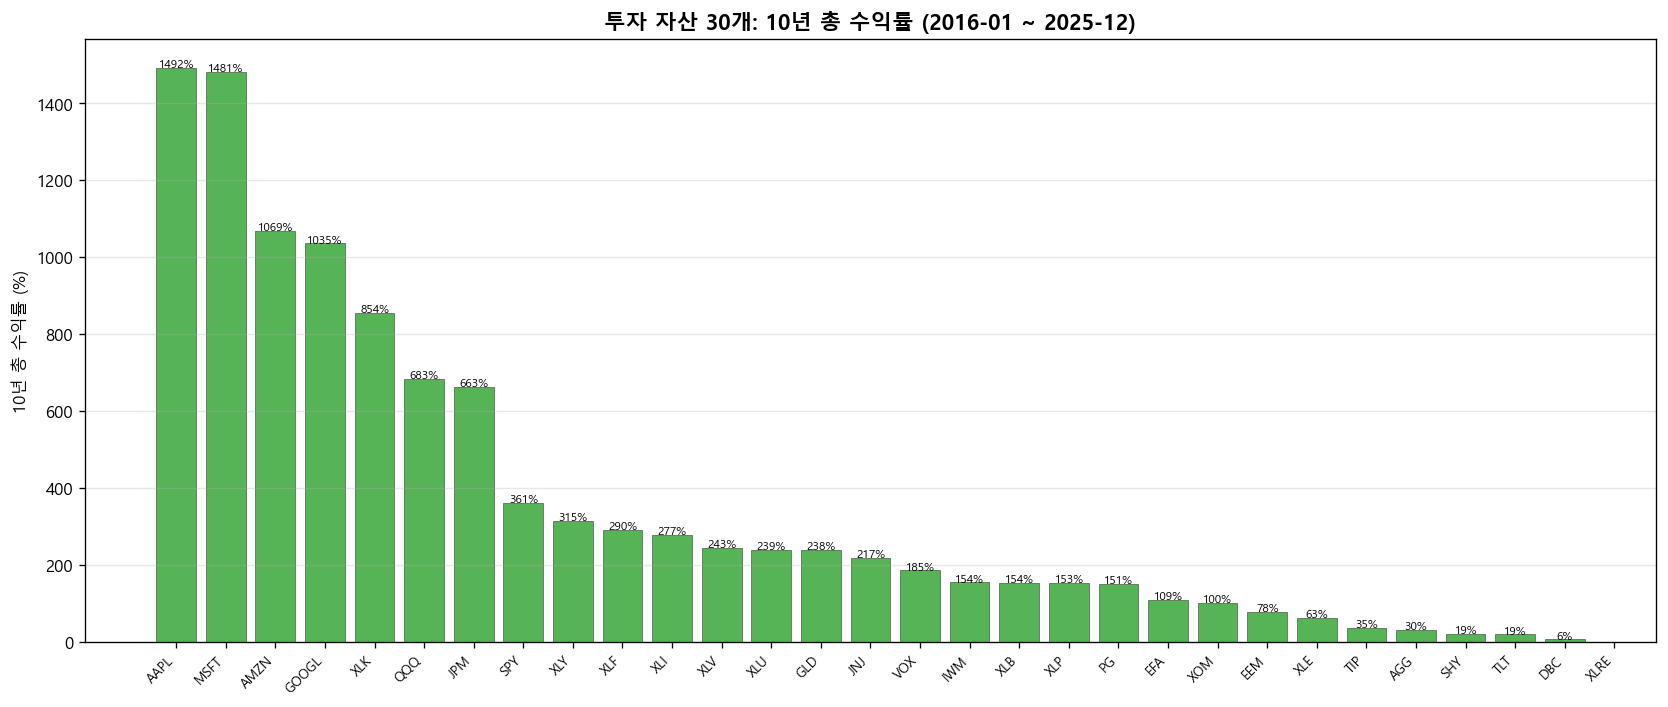

저장: images/step1_01_total_returns.png


In [27]:
# ============================================================
# 투자 자산 기초 통계 (시작/종료 가격, 10년 수익률)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# 10년 총 수익률
total_ret = (df_portfolio.iloc[-1] / df_portfolio.iloc[0] - 1) * 100
total_ret = total_ret.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in total_ret]
bars = ax.bar(range(len(total_ret)), total_ret, color=colors, alpha=0.8, edgecolor='black', linewidth=0.3)
ax.set_xticks(range(len(total_ret)))
ax.set_xticklabels(total_ret.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('10년 총 수익률 (%)')
ax.set_title('투자 자산 30개: 10년 총 수익률 (2016-01 ~ 2025-12)', fontsize=13, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# 값 라벨
for bar, val in zip(bars, total_ret):
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y + (2 if y >= 0 else -8),
            f'{val:.0f}%', ha='center', fontsize=7)

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'step1_01_total_returns.png'), bbox_inches='tight')
plt.show()
print('저장: images/step1_01_total_returns.png')

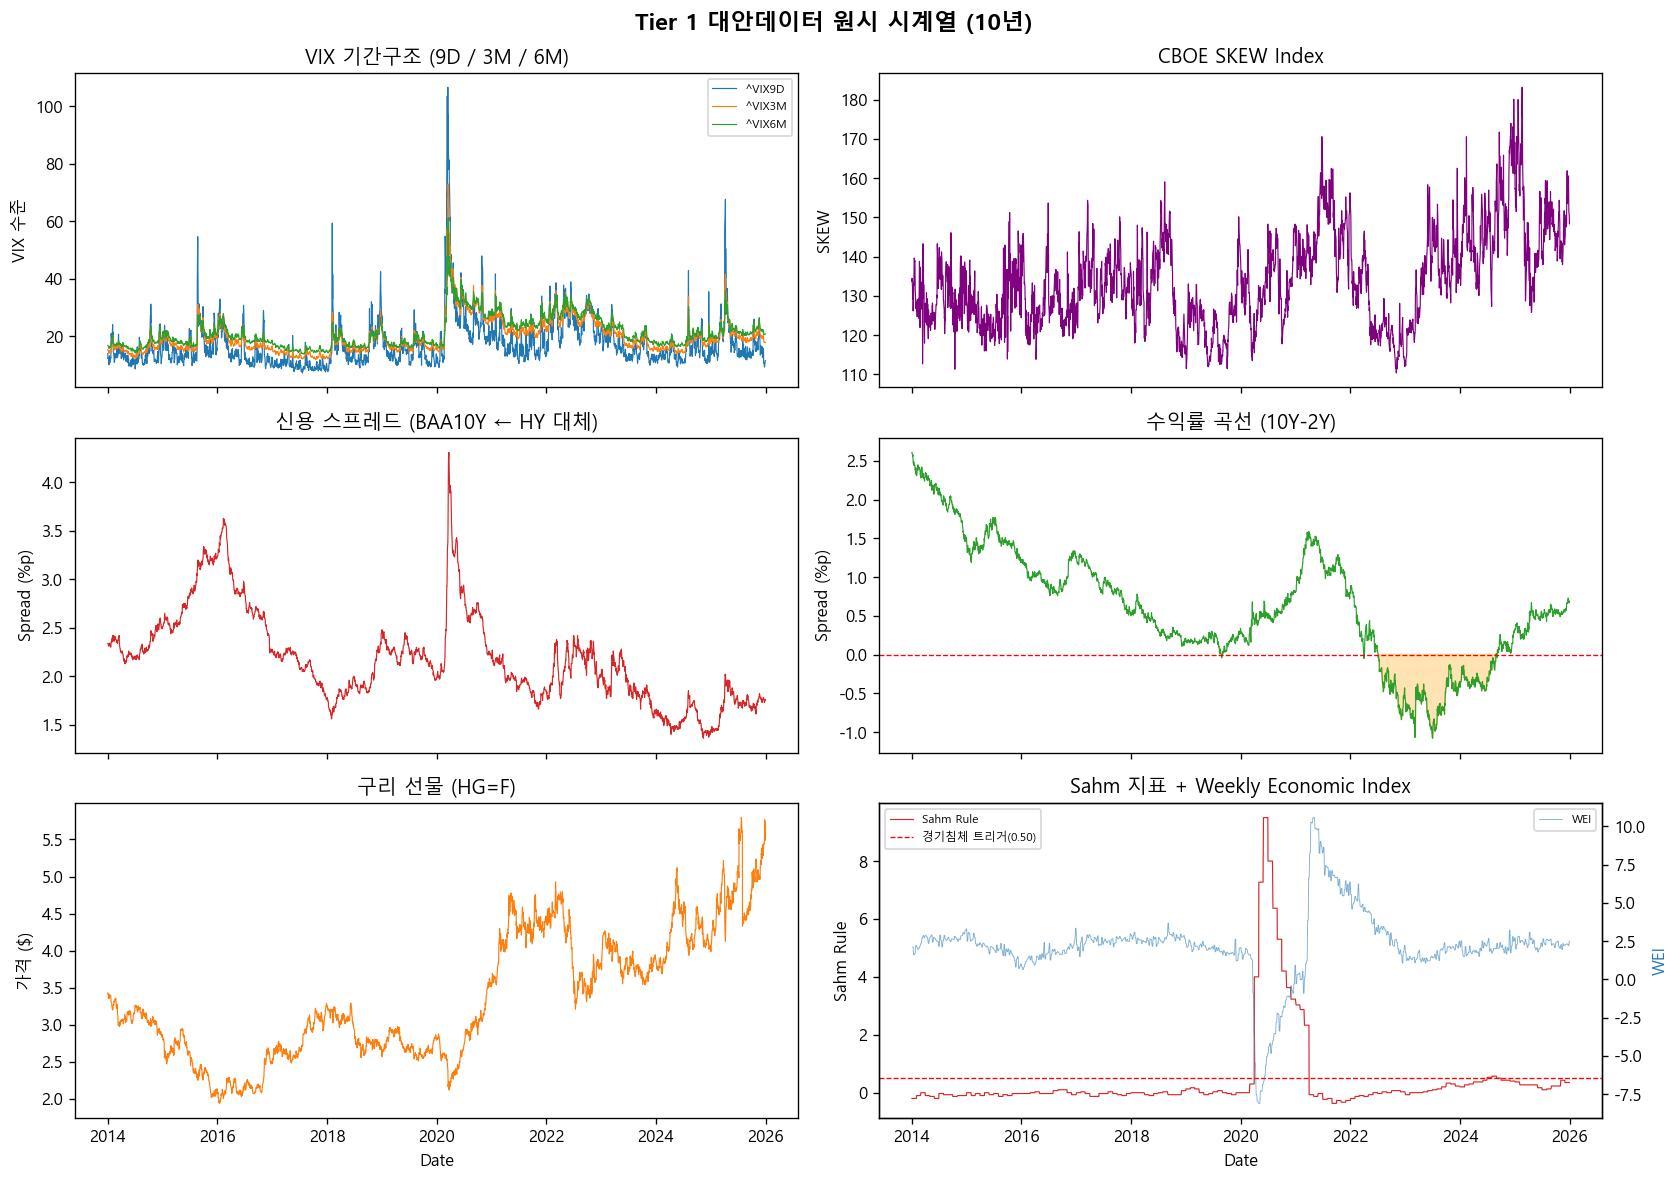

저장: images/step1_02_alt_data_preview.png


In [28]:
# ============================================================
# 대안데이터 시계열 미리보기
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
fig.suptitle('Tier 1 대안데이터 원시 시계열 (10년)', fontsize=14, fontweight='bold')

# VIX 기간구조
ax = axes[0, 0]
for t in ['^VIX9D', '^VIX3M', '^VIX6M']:
    if t in df_ext_alt.columns:
        ax.plot(df_ext_alt.index, df_ext_alt[t], linewidth=0.7, label=t)
ax.set_title('VIX 기간구조 (9D / 3M / 6M)')
ax.legend(fontsize=7)
ax.set_ylabel('VIX 수준')

# SKEW
ax = axes[0, 1]
if '^SKEW' in df_ext_alt.columns:
    ax.plot(df_ext_alt.index, df_ext_alt['^SKEW'], linewidth=0.7, color='purple')
ax.set_title('CBOE SKEW Index')
ax.set_ylabel('SKEW')

# 신용 스프레드 (BAA10Y ← BAMLH0A0HYM2 대체, ICE 라이선스 3년 제약)
ax = axes[1, 0]
ax.plot(df_fred.index, df_fred['BAA10Y'], linewidth=0.7, color='#d62728')
ax.set_title('신용 스프레드 (BAA10Y ← HY 대체)')
ax.set_ylabel('Spread (%p)')

# 수익률 곡선
ax = axes[1, 1]
ax.plot(df_fred.index, df_fred['T10Y2Y'], linewidth=0.7, color='#2ca02c')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.fill_between(df_fred.index, df_fred['T10Y2Y'], 0,
                where=df_fred['T10Y2Y'] < 0, color='orange', alpha=0.3)
ax.set_title('수익률 곡선 (10Y-2Y)')
ax.set_ylabel('Spread (%p)')

# 구리 선물
ax = axes[2, 0]
if 'HG=F' in df_ext_alt.columns:
    ax.plot(df_ext_alt.index, df_ext_alt['HG=F'], linewidth=0.7, color='#ff7f0e')
ax.set_title('구리 선물 (HG=F)')
ax.set_ylabel('가격 ($)')
ax.set_xlabel('Date')

# Sahm + WEI
ax = axes[2, 1]
ax.plot(df_fred.index, df_fred['SAHMREALTIME'], linewidth=0.7, color='#d62728', label='Sahm Rule')
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='경기침체 트리거(0.50)')
ax2 = ax.twinx()
ax2.plot(df_fred.index, df_fred['WEI'], linewidth=0.5, color='#1f77b4', alpha=0.6, label='WEI')
ax2.set_ylabel('WEI', color='#1f77b4')
ax.set_title('Sahm 지표 + Weekly Economic Index')
ax.set_ylabel('Sahm Rule')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=7)
ax2.legend(loc='upper right', fontsize=7)

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'step1_02_alt_data_preview.png'), bbox_inches='tight')
plt.show()
print('저장: images/step1_02_alt_data_preview.png')

In [29]:
# ============================================================
# CSV 저장
# ============================================================

saves = {
    'portfolio_prices.csv': df_portfolio,
    'external_prices.csv': df_ext_alt,
    'fred_data.csv': df_fred,
}

print('=== CSV 저장 ===')
for fname, df in saves.items():
    path = os.path.join(DATA_DIR, fname)
    df.to_csv(path)
    size_kb = os.path.getsize(path) / 1024
    print(f'  {fname:30s} | {df.shape[0]:,}행 × {df.shape[1]:,}열 | {size_kb:.0f} KB')

print(f'\n저장 경로: {DATA_DIR}')
print('Step1 완료.')

=== CSV 저장 ===
  portfolio_prices.csv           | 3,017행 × 30열 | 1639 KB
  external_prices.csv            | 3,017행 × 11열 | 606 KB
  fred_data.csv                  | 3,017행 × 8열 | 171 KB

저장 경로: c:\workspace\camp\project\finance_project\서윤범\data
Step1 완료.


In [8]:
# ── Imports & Data Loading ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os, pathlib

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

BASE = pathlib.Path('.')
DATA = BASE / 'data'
IMG  = BASE / 'images'
IMG.mkdir(exist_ok=True)

# ── 분석 기간 상수 ────────────────────────────────────────────
# Step1에서 데이터는 WARMUP_START(2014-01-01)부터 수집됨
# 파생변수 계산은 전체 기간(2014~)으로 수행하고, 최종 df_reg_v2는 2016-01-01부터 슬라이싱
ANALYSIS_START = '2016-01-01'

# 데이터 로드 (Step1에서 WARMUP_START 기준으로 저장된 파일)
portfolio_prices = pd.read_csv(DATA / 'portfolio_prices.csv', index_col=0, parse_dates=True)
external_prices  = pd.read_csv(DATA / 'external_prices.csv',  index_col=0, parse_dates=True)
fred_data        = pd.read_csv(DATA / 'fred_data.csv',        index_col=0, parse_dates=True)

print(f'portfolio_prices : {portfolio_prices.shape}')
print(f'external_prices  : {external_prices.shape}')
print(f'fred_data        : {fred_data.shape}')
print(f'\n분석 기간 슬라이싱 기준: {ANALYSIS_START}')

# ── 자산 그룹 정의 ──
INDEX_ETF  = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']
BOND_ETF   = ['TLT', 'AGG', 'SHY', 'TIP']
ALT_ETF    = ['GLD', 'DBC']
SECTOR_ETF = ['XLK', 'XLF', 'XLE', 'XLV', 'VOX', 'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']
STOCKS     = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']

EQUITY_TICKERS = INDEX_ETF + SECTOR_ETF + STOCKS  # 24 items
ALL_TICKERS    = INDEX_ETF + BOND_ETF + ALT_ETF + SECTOR_ETF + STOCKS  # 30 items

print(f'\nEQUITY_TICKERS : {len(EQUITY_TICKERS)}개')
print(f'ALL_TICKERS    : {len(ALL_TICKERS)}개')

portfolio_prices : (3017, 30)
external_prices  : (3017, 11)
fred_data        : (3017, 8)

분석 기간 슬라이싱 기준: 2016-01-01

EQUITY_TICKERS : 24개
ALL_TICKERS    : 30개


In [9]:
# ── 2-1. 수익률 계산 ──────────────────────────────────────────

# (1) 포트폴리오 로그 수익률
port_ret = np.log(portfolio_prices / portfolio_prices.shift(1)).dropna()
print(f'포트폴리오 로그 수익률 : {port_ret.shape}')

# (2) 외부 지표 수익률 — VIX 계열은 수준 차분
VIX_COLS = [c for c in external_prices.columns if 'VIX' in c.upper()]
NON_VIX  = [c for c in external_prices.columns if c not in VIX_COLS]

ext_ret_logpart = np.log(external_prices[NON_VIX] / external_prices[NON_VIX].shift(1))
ext_ret_vixpart = external_prices[VIX_COLS].diff()
ext_ret = pd.concat([ext_ret_logpart, ext_ret_vixpart], axis=1).dropna()

print(f'외부 지표 수익률     : {ext_ret.shape}')
print(f'  - VIX 차분 컬럼   : {VIX_COLS}')
print(f'  - 로그 수익률 컬럼 : {NON_VIX}')

포트폴리오 로그 수익률 : (2571, 30)
외부 지표 수익률     : (2836, 11)
  - VIX 차분 컬럼   : ['^VIX', '^VIX9D', '^VIX3M', '^VIX6M']
  - 로그 수익률 컬럼 : ['CL=F', 'GC=F', 'SI=F', 'BTC-USD', 'DX-Y.NYB', '^SKEW', 'HG=F']


In [ ]:
# ── 2-2. 13개 파생 변수 생성 ─────────────────────────────────
#
# 롤링 윈도우 주의:
#   - SKEW_zscore    : 63일 롤링  → 워밍업 기간(2014~2015) 덕분에 2016-01 기준값이 안정화됨
#   - Cu_Au_ratio_chg: 21일 pct_change
#   - claims_4wma    : 20일(4주) 롤링 이동평균
#   - claims_zscore  : 260일(약 1년) 롤링 → 가장 긴 윈도우; 워밍업 없으면 2016년 초 z-score 불안정
#
# WEI·SAHMREALTIME 제거 (2026-04):
#   PIT 적용 시 WEI는 2020-04, SAHMREALTIME은 2019-09 이전 NaN → dropna로 분석 기간 4년 축소
#   → df_reg_v2에서 제외, features.csv 원본엔 보존, Step 6은 fred_data.csv에서 별도 로드
#
# 이 셀은 portfolio_prices 전체 기간(2014~2025)으로 계산하고,
# 슬라이싱은 cell-7(df_reg_v2 구축) 이후 ANALYSIS_START 기준으로 수행합니다.
feat = pd.DataFrame(index=portfolio_prices.index)

# 변동성 기간구조
feat['VIX_contango']     = external_prices['^VIX3M'] / external_prices['^VIX'] - 1
feat['VIX_slope_9d_3m']  = external_prices['^VIX3M'] - external_prices['^VIX9D']
feat['VIX_slope_3m_6m']  = external_prices['^VIX6M'] - external_prices['^VIX3M']

# 테일 리스크
feat['SKEW_level']  = external_prices['^SKEW']
skew_roll = external_prices['^SKEW'].rolling(63)  # 63일 = 약 3개월
feat['SKEW_zscore'] = (external_prices['^SKEW'] - skew_roll.mean()) / skew_roll.std()

# 구리/금 경기 심리
feat['Cu_Au_ratio']     = external_prices['HG=F'] / external_prices['GC=F']
feat['Cu_Au_ratio_chg'] = feat['Cu_Au_ratio'].pct_change(21)

# 신용 스프레드 — BAMLH0A0HYM2(HY) → BAA10Y 대체 (2026-04 ICE 라이선스 3년 제약)
feat['HY_spread']     = fred_data['BAA10Y']         # ← 변경 (변수명은 유지)
feat['HY_spread_chg'] = fred_data['BAA10Y'].diff(5) # ← 변경

# 수익률 곡선
feat['yield_curve']     = fred_data['T10Y2Y']
feat['yield_curve_inv'] = (fred_data['T10Y2Y'] < 0).astype(int)

# 고용 지표 — 롤링 윈도우가 크므로 워밍업 기간이 특히 중요한 변수
feat['claims_4wma']  = fred_data['ICSA'].rolling(20).mean()        # 4주 × 5일 = 20 거래일
icsa_roll = fred_data['ICSA'].rolling(260)                          # 260일 ≈ 1년
feat['claims_zscore'] = (fred_data['ICSA'] - icsa_roll.mean()) / icsa_roll.std()

# (WEI_level, sahm_indicator 제거 — PIT 소급창조 데이터 배제)

FEATURE_NAMES = list(feat.columns)
print(f'파생 변수 {len(FEATURE_NAMES)}개 생성 완료 (전체 기간 포함, 슬라이싱 전)')
print(feat.tail(3))

# 저장 (전체 기간 포함 — 슬라이싱 전 원본)
feat.to_csv(DATA / 'features.csv')
print(f'\n→ data/features.csv 저장 ({feat.shape})')